In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.metrics import ndcg_score

OUT_DIR = Path(
    "/Users/kevinbauer/Desktop/Masterarbeit/Supervised Phase/data/Final data/Supervised_ensemble"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

ALL_DATASETS = [
    "UBE4B",
    "GRB2",
    "PTEN_activity",
    "PTEN_abundance",
    "Alpha-Amylase_expression",
    "Alpha-Amylase_thermostability",
    "Alpha-Amylase_specific_activity",
]

OPTIMIZATION_DATASETS = [
    "GRB2",
    "PTEN_activity",
    "PTEN_abundance",
    "Alpha-Amylase_expression",
]

DATASET_PRETTY = {
    "UBE4B": "UBE4B",
    "GRB2": "GRB2",
    "PTEN_activity": "PTEN activity",
    "PTEN_abundance": "PTEN abundance",
    "Alpha-Amylase_expression": "Alpha-Amylase expression",
    "Alpha-Amylase_thermostability": "Alpha-Amylase thermostability",
    "Alpha-Amylase_specific_activity": "Alpha-Amylase specific activity",
}

TOP_FRAC = 0.10
WEIGHT_STEP = 0.01
GLOBAL_OPTIMIZE_FOR = "mean_both"


def make_nonnegative_relevance(values):
    values = np.asarray(values, dtype=float)
    values = values - np.nanmin(values)
    return np.clip(values, 0.0, None)


def ndcg_at_fraction(y_true, y_score, frac=0.10):
    y_true = pd.to_numeric(pd.Series(y_true), errors="coerce").to_numpy(float)
    y_score = pd.to_numeric(pd.Series(y_score), errors="coerce").to_numpy(float)

    mask = np.isfinite(y_true) & np.isfinite(y_score)
    y_true = y_true[mask]
    y_score = y_score[mask]

    if len(y_true) < 3:
        return np.nan

    k = max(1, int(np.ceil(frac * len(y_true))))
    relevance = make_nonnegative_relevance(y_true)

    if np.max(relevance) == 0:
        return np.nan

    return float(ndcg_score(relevance.reshape(1, -1), y_score.reshape(1, -1), k=k))


def compute_rank_metrics(y_true, score):
    y_true = pd.to_numeric(pd.Series(y_true), errors="coerce").to_numpy(float)
    score = pd.to_numeric(pd.Series(score), errors="coerce").to_numpy(float)

    mask = np.isfinite(y_true) & np.isfinite(score)
    y_true = y_true[mask]
    score = score[mask]

    if len(y_true) < 3 or np.std(score) == 0:
        return {"n": int(len(y_true)), "spearman": np.nan, "ndcg_10": np.nan}

    return {
        "n": int(len(y_true)),
        "spearman": float(spearmanr(y_true, score).correlation),
        "ndcg_10": ndcg_at_fraction(y_true, score, frac=TOP_FRAC),
    }


def rank_normalize(x):
    return pd.Series(x).rank(method="average", pct=True).to_numpy(float)


def objective_from_summary(row):
    if GLOBAL_OPTIMIZE_FOR == "mean_spearman":
        return row["mean_spearman"]
    if GLOBAL_OPTIMIZE_FOR == "mean_ndcg_10":
        return row["mean_ndcg_10"]
    if GLOBAL_OPTIMIZE_FOR == "mean_both":
        return (row["mean_spearman"] + row["mean_ndcg_10"]) / 2.0
    raise ValueError(f"Unknown GLOBAL_OPTIMIZE_FOR: {GLOBAL_OPTIMIZE_FOR}")


def generate_weight_grid_two(step=0.01):
    values = np.round(np.arange(0.0, 1.0 + 1e-9, step), 10)
    return [
        {"w_esm2": float(w), "w_foldvision": float(1.0 - w)}
        for w in values
    ]


def generate_weight_grid_three(step=0.01):
    values = np.round(np.arange(0.0, 1.0 + 1e-9, step), 10)
    weights = []

    for w_esm2 in values:
        for w_foldvision in values:
            w_kermut = 1.0 - w_esm2 - w_foldvision
            if w_kermut >= -1e-9:
                weights.append({
                    "w_esm2": float(round(w_esm2, 10)),
                    "w_foldvision": float(round(w_foldvision, 10)),
                    "w_kermut": float(round(w_kermut, 10)),
                })

    return weights


def weighted_score_two(df, weights):
    return (
        weights["w_esm2"] * df["esm2_rank"]
        + weights["w_foldvision"] * df["foldvision_rank"]
    )


def weighted_score_three(df, weights):
    return (
        weights["w_esm2"] * df["esm2_rank"]
        + weights["w_foldvision"] * df["foldvision_rank"]
        + weights["w_kermut"] * df["kermut_rank"]
    )


def summarize_weight_search(weight_search_df):
    weight_cols = [c for c in weight_search_df.columns if c.startswith("w_")]

    summary = (
        weight_search_df
        .groupby(weight_cols, as_index=False)
        .agg(
            mean_spearman=("spearman", "mean"),
            mean_ndcg_10=("ndcg_10", "mean"),
            min_spearman=("spearman", "min"),
            min_ndcg_10=("ndcg_10", "min"),
            n_datasets=("dataset", "nunique"),
        )
    )

    summary["mean_both"] = (
        summary["mean_spearman"] + summary["mean_ndcg_10"]
    ) / 2.0

    summary["objective"] = summary.apply(objective_from_summary, axis=1)

    return summary.sort_values("objective", ascending=False).reset_index(drop=True)


merged_rows = []
baseline_rows = []

for dataset in ALL_DATASETS:
    pred_path = OUT_DIR / f"{dataset}_esm2_foldvision_kermut_rank_ensemble_test_predictions.csv"

    if not pred_path.exists():
        print(f"[WARN] Missing prediction file: {pred_path}")
        continue

    df = pd.read_csv(pred_path)
    df = df.drop_duplicates(subset=["variant"], keep="first").copy()

    required_cols = {"variant", "y_true", "esm2_pred", "foldvision_pred", "kermut_pred"}
    missing = required_cols - set(df.columns)

    if missing:
        raise ValueError(f"{dataset}: missing columns {missing}")

    df["esm2_rank"] = rank_normalize(df["esm2_pred"])
    df["foldvision_rank"] = rank_normalize(df["foldvision_pred"])
    df["kermut_rank"] = rank_normalize(df["kermut_pred"])

    df["dataset"] = dataset
    df["dataset_pretty"] = DATASET_PRETTY[dataset]

    merged_rows.append(df)

    for method, score_col in {
        "Fine-tuned ESM-2": "esm2_rank",
        "FoldVision": "foldvision_rank",
        "Kermut": "kermut_rank",
    }.items():
        metrics = compute_rank_metrics(df["y_true"], df[score_col])

        baseline_rows.append({
            "dataset": dataset,
            "dataset_pretty": DATASET_PRETTY[dataset],
            "method": method,
            **metrics,
        })

baseline_df = pd.DataFrame(baseline_rows)

optimization_rows = [
    df for df in merged_rows
    if df["dataset"].iloc[0] in OPTIMIZATION_DATASETS
]

# ESM-2 + FoldVision ensemble
weight_rows_two = []

for weights in generate_weight_grid_two(step=WEIGHT_STEP):
    for df in optimization_rows:
        metrics = compute_rank_metrics(df["y_true"], weighted_score_two(df, weights))

        weight_rows_two.append({
            "dataset": df["dataset"].iloc[0],
            **weights,
            **metrics,
        })

weight_search_two_df = pd.DataFrame(weight_rows_two)
weight_summary_two_df = summarize_weight_search(weight_search_two_df)

BEST_WEIGHTS_TWO = {
    "w_esm2": float(weight_summary_two_df.iloc[0]["w_esm2"]),
    "w_foldvision": float(weight_summary_two_df.iloc[0]["w_foldvision"]),
}

# ESM-2 + FoldVision + Kermut ensemble
weight_rows_three = []

for weights in generate_weight_grid_three(step=WEIGHT_STEP):
    for df in optimization_rows:
        metrics = compute_rank_metrics(df["y_true"], weighted_score_three(df, weights))

        weight_rows_three.append({
            "dataset": df["dataset"].iloc[0],
            **weights,
            **metrics,
        })

weight_search_three_df = pd.DataFrame(weight_rows_three)
weight_summary_three_df = summarize_weight_search(weight_search_three_df)

BEST_WEIGHTS_THREE = {
    "w_esm2": float(weight_summary_three_df.iloc[0]["w_esm2"]),
    "w_foldvision": float(weight_summary_three_df.iloc[0]["w_foldvision"]),
    "w_kermut": float(weight_summary_three_df.iloc[0]["w_kermut"]),
}

ensemble_rows = []

for df in merged_rows:
    dataset = df["dataset"].iloc[0]
    dataset_pretty = DATASET_PRETTY[dataset]

    score_two = weighted_score_two(df, BEST_WEIGHTS_TWO)
    metrics_two = compute_rank_metrics(df["y_true"], score_two)

    ensemble_rows.append({
        "dataset": dataset,
        "dataset_pretty": dataset_pretty,
        "method": "ESM-2 + FoldVision weighted rank ensemble",
        **BEST_WEIGHTS_TWO,
        **metrics_two,
    })

    score_three = weighted_score_three(df, BEST_WEIGHTS_THREE)
    metrics_three = compute_rank_metrics(df["y_true"], score_three)

    ensemble_rows.append({
        "dataset": dataset,
        "dataset_pretty": dataset_pretty,
        "method": "ESM-2 + FoldVision + Kermut weighted rank ensemble",
        **BEST_WEIGHTS_THREE,
        **metrics_three,
    })

ensemble_df = pd.DataFrame(ensemble_rows)

comparison_df = pd.concat(
    [baseline_df, ensemble_df],
    ignore_index=True,
)

tag = (
    "supervised_weighted_rank_ensembles"
    "_optimized_on_selected_reference_tasks"
    f"_step_{WEIGHT_STEP}"
    f"_opt_{GLOBAL_OPTIMIZE_FOR}"
)

comparison_path = OUT_DIR / f"{tag}_comparison.tsv"
weight_summary_two_path = OUT_DIR / f"{tag}_esm2_foldvision_weight_summary.tsv"
weight_summary_three_path = OUT_DIR / f"{tag}_esm2_foldvision_kermut_weight_summary.tsv"

comparison_df.to_csv(comparison_path, sep="\t", index=False)
weight_summary_two_df.to_csv(weight_summary_two_path, sep="\t", index=False)
weight_summary_three_df.to_csv(weight_summary_three_path, sep="\t", index=False)

print("Best ESM-2 + FoldVision weights:")
print(BEST_WEIGHTS_TWO)

print("\nBest ESM-2 + FoldVision + Kermut weights:")
print(BEST_WEIGHTS_THREE)

print("\nSaved:")
print(comparison_path)
print(weight_summary_two_path)
print(weight_summary_three_path)

display(comparison_df)

Best ESM-2 + FoldVision weights:
{'w_esm2': 0.75, 'w_foldvision': 0.25}

Best ESM-2 + FoldVision + Kermut weights:
{'w_esm2': 0.3, 'w_foldvision': 0.06, 'w_kermut': 0.64}

Saved:
/Users/kevinbauer/Desktop/Masterarbeit/Supervised Phase/data/Final data/Supervised_ensemble/supervised_weighted_rank_ensembles_optimized_on_selected_reference_tasks_step_0.01_opt_mean_both_comparison.tsv
/Users/kevinbauer/Desktop/Masterarbeit/Supervised Phase/data/Final data/Supervised_ensemble/supervised_weighted_rank_ensembles_optimized_on_selected_reference_tasks_step_0.01_opt_mean_both_esm2_foldvision_weight_summary.tsv
/Users/kevinbauer/Desktop/Masterarbeit/Supervised Phase/data/Final data/Supervised_ensemble/supervised_weighted_rank_ensembles_optimized_on_selected_reference_tasks_step_0.01_opt_mean_both_esm2_foldvision_kermut_weight_summary.tsv


,dataset,dataset_pretty,method,n,spearman,ndcg_10,w_esm2,w_foldvision,w_kermut
0,UBE4B,UBE4B,Fine-tuned ESM-2,94,0.512136,0.723967,NaN,NaN,NaN
1,UBE4B,UBE4B,FoldVision,94,-0.200188,0.504002,NaN,NaN,NaN
2,UBE4B,UBE4B,Kermut,94,0.669371,0.769505,NaN,NaN,NaN
3,GRB2,GRB2,Fine-tuned ESM-2,104,0.836040,0.963462,NaN,NaN,NaN
4,GRB2,GRB2,FoldVision,104,0.686152,0.774182,NaN,NaN,NaN
5,GRB2,GRB2,Kermut,104,0.890867,0.963262,NaN,NaN,NaN
6,PTEN_activity,PTEN activity,Fine-tuned ESM-2,657,0.598448,0.862349,NaN,NaN,NaN
7,PTEN_activity,PTEN activity,FoldVision,657,0.524449,0.814717,NaN,NaN,NaN
8,PTEN_activity,PTEN activity,Kermut,657,0.611986,0.865402,NaN,NaN,NaN
9,PTEN_abundance,PTEN abundance,Fine-tuned ESM-2,439,0.726057,0.854868,NaN,NaN,NaN


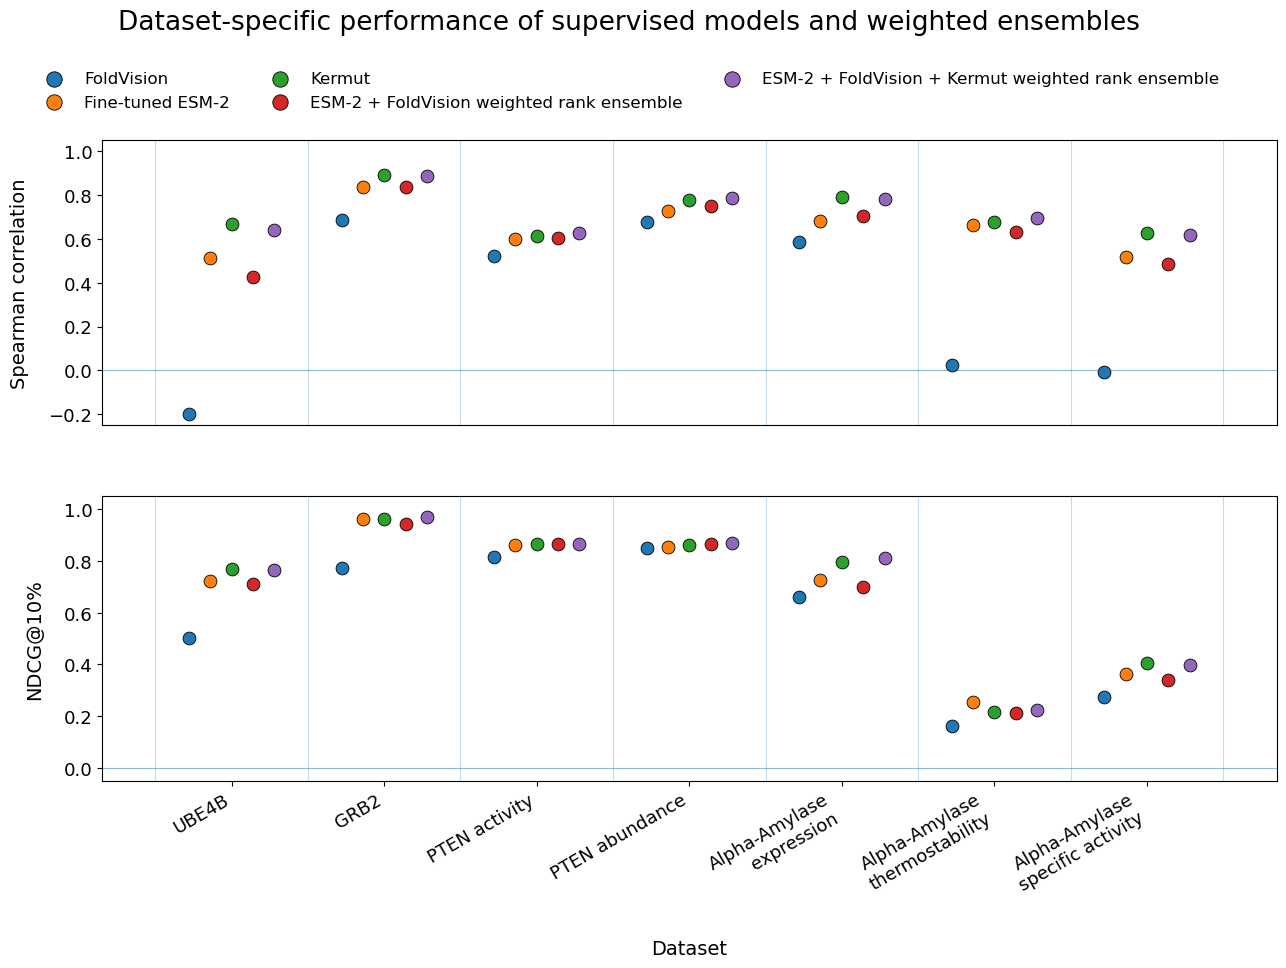

Saved PNG to: /Users/kevinbauer/Desktop/Masterarbeit/Supervised Phase/plots/supervised_models_weighted_ensembles_selected_optimization_spearman_ndcg10_dotplot.png
Saved PDF to: /Users/kevinbauer/Desktop/Masterarbeit/Supervised Phase/plots/supervised_models_weighted_ensembles_selected_optimization_spearman_ndcg10_dotplot.pdf


In [5]:
import matplotlib.pyplot as plt

PLOT_DIR = Path(
    "/Users/kevinbauer/Desktop/Masterarbeit/Supervised Phase/plots"
)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

dataset_order = [
    "UBE4B",
    "GRB2",
    "PTEN activity",
    "PTEN abundance",
    "Alpha-Amylase expression",
    "Alpha-Amylase thermostability",
    "Alpha-Amylase specific activity",
]

model_order = [
    "FoldVision",
    "Fine-tuned ESM-2",
    "Kermut",
    "ESM-2 + FoldVision weighted rank ensemble",
    "ESM-2 + FoldVision + Kermut weighted rank ensemble",
]

metrics = [
    ("spearman", "Spearman correlation"),
    ("ndcg_10", "NDCG@10%"),
]


def wrap_task_label(label):
    label = str(label)
    if label.startswith("Alpha-Amylase "):
        return label.replace("Alpha-Amylase ", "Alpha-Amylase\n")
    return label


plot_input = comparison_df[
    comparison_df["method"].isin(model_order)
].copy()

plot_input["method"] = pd.Categorical(
    plot_input["method"],
    categories=model_order,
    ordered=True,
)

plot_input["dataset_pretty"] = pd.Categorical(
    plot_input["dataset_pretty"],
    categories=dataset_order,
    ordered=True,
)

plot_input = plot_input.sort_values(["dataset_pretty", "method"])


def plot_grouped_metrics_dotplot(plot_input, metrics, title, out_name):
    x_positions = np.arange(len(dataset_order))
    offsets = np.linspace(-0.28, 0.28, len(model_order))

    fig, axes = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(13.5, 10.5),
        sharex=True,
    )

    for plot_idx, (ax, (metric, ylabel)) in enumerate(zip(axes, metrics)):
        plot_df = plot_input.dropna(subset=[metric]).copy()

        for model, offset in zip(model_order, offsets):
            xs = []
            values = []

            for i, dataset in enumerate(dataset_order):
                subset = plot_df[
                    (plot_df["dataset_pretty"].astype(str) == dataset)
                    & (plot_df["method"].astype(str) == model)
                ]

                if len(subset) > 0:
                    xs.append(i + offset)
                    values.append(subset[metric].iloc[0])

            ax.scatter(
                xs,
                values,
                s=85,
                label=model,
                edgecolor="black",
                linewidth=0.6,
                zorder=3,
            )

        for i in range(len(dataset_order) + 1):
            ax.axvline(i - 0.5, linewidth=0.8, alpha=0.25, zorder=1)

        ax.axhline(0, linewidth=0.8, alpha=0.5)
        ax.set_ylabel(ylabel, fontsize=14, labelpad=14)
        ax.tick_params(axis="y", labelsize=13)

        if metric == "ndcg_10":
            ax.set_ylim(-0.05, 1.05)
        else:
            ax.set_ylim(-0.25, 1.05)

        if plot_idx == 0:
            ax.set_xticklabels([])
            ax.tick_params(axis="x", length=0)

    axes[-1].set_xticks(x_positions)
    axes[-1].set_xticklabels(
        [wrap_task_label(label) for label in dataset_order],
        rotation=30,
        ha="right",
        fontsize=13,
    )
    axes[-1].set_xlabel("Dataset", fontsize=14, labelpad=32)

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.94),
        ncol=3,
        frameon=False,
        fontsize=12,
        markerscale=1.2,
    )

    fig.suptitle(title, fontsize=19, y=0.985)

    fig.subplots_adjust(
        top=0.86,
        bottom=0.25,
        left=0.11,
        right=0.98,
        hspace=0.25,
    )

    out_png = PLOT_DIR / f"{out_name}.png"
    out_pdf = PLOT_DIR / f"{out_name}.pdf"

    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.savefig(out_pdf, bbox_inches="tight")
    plt.show()

    print(f"Saved PNG to: {out_png}")
    print(f"Saved PDF to: {out_pdf}")


plot_grouped_metrics_dotplot(
    plot_input=plot_input,
    metrics=metrics,
    title="Dataset-specific performance of supervised models and weighted ensembles",
    out_name="supervised_models_weighted_ensembles_selected_optimization_spearman_ndcg10_dotplot",
)

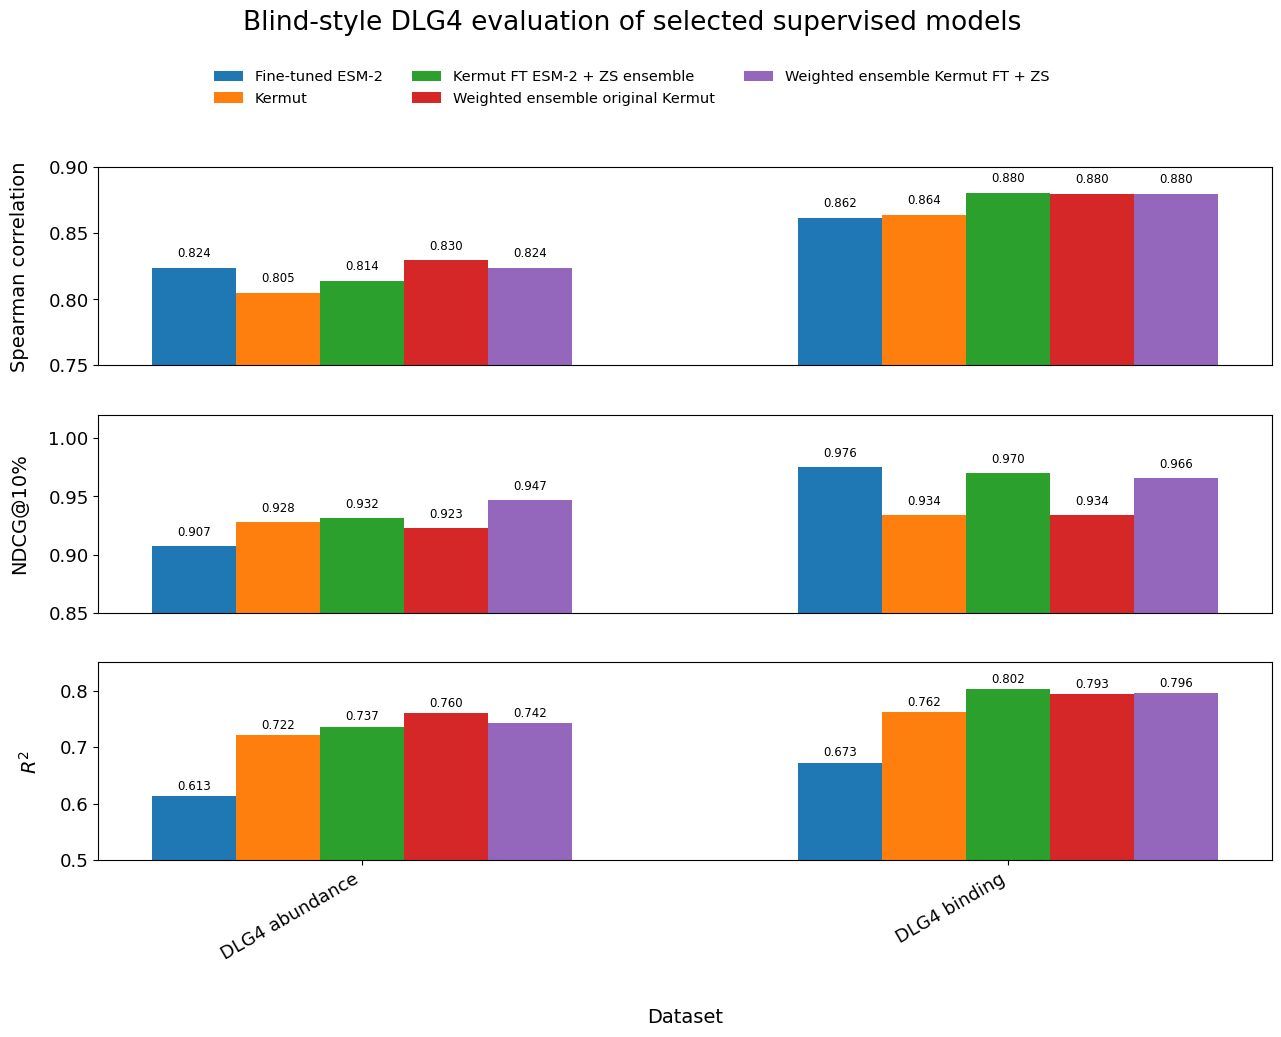

Saved PNG to: /Users/kevinbauer/Desktop/Masterarbeit/Supervised Phase/plots/DLG4_blind_style_selected_supervised_models_spearman_ndcg10_r2_zoomed.png
Saved PDF to: /Users/kevinbauer/Desktop/Masterarbeit/Supervised Phase/plots/DLG4_blind_style_selected_supervised_models_spearman_ndcg10_r2_zoomed.pdf


In [6]:
import re
from sklearn.metrics import r2_score

BASE = Path("/Users/kevinbauer/Desktop/Masterarbeit/Supervised Phase/data/Final data")

ESM2_BASE = BASE / "ESM2"
FOLDVISION_BASE = BASE / "FoldVision"

KERMUT_ORIGINAL_PRED_BASE = (
    BASE / "Kermut" / "original" / "results" / "predictions"
)

KERMUT_FT_ZS_PRED_BASE = (
    BASE
    / "Kermut"
    / "variant_runs"
    / "finetuned_ensemble"
    / "predictions"
)

BLIND_DATASETS = [
    "DLG4_abundance",
    "DLG4_binding",
]

DATASET_PRETTY_DLG4 = {
    "DLG4_abundance": "DLG4 abundance",
    "DLG4_binding": "DLG4 binding",
}

VARIANT_TOKEN_RE = re.compile(r"[A-Z]\d+[A-Z]")

WEIGHTS_ORIGINAL_KERMUT = BEST_WEIGHTS_THREE.copy()
WEIGHTS_FT_ZS_KERMUT = BEST_WEIGHTS_THREE.copy()


def normalize_variant(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip()
    x = x.replace(".npz", "")
    x = x.replace(".pdb", "")
    x = x.replace(".csv", "")
    x = x.replace(" ", "")

    tokens = VARIANT_TOKEN_RE.findall(x)

    if len(tokens) > 0:
        return ",".join(tokens)

    for prefix in ["DLG4_abundance_", "DLG4_binding_", "DLG4_"]:
        if x.startswith(prefix):
            x = x[len(prefix):]

    return x


def shift_variant_positions(variant, shift):
    if pd.isna(variant):
        return np.nan

    def repl(match):
        wt = match.group(1)
        pos = int(match.group(2))
        mt = match.group(3)
        return f"{wt}{pos + shift}{mt}"

    return re.sub(r"([A-Z])(\d+)([A-Z])", repl, str(variant))


def compute_raw_r2(y_true, y_pred):
    y_true = pd.to_numeric(pd.Series(y_true), errors="coerce").to_numpy(float)
    y_pred = pd.to_numeric(pd.Series(y_pred), errors="coerce").to_numpy(float)

    mask = np.isfinite(y_true) & np.isfinite(y_pred)

    if mask.sum() < 3:
        return np.nan

    return float(r2_score(y_true[mask], y_pred[mask]))


def affine_map_prediction_to_target_scale(source_y, target_y, source_pred):
    source_y = pd.to_numeric(pd.Series(source_y), errors="coerce").to_numpy(float)
    target_y = pd.to_numeric(pd.Series(target_y), errors="coerce").to_numpy(float)
    source_pred = pd.to_numeric(pd.Series(source_pred), errors="coerce").to_numpy(float)

    mask_fit = np.isfinite(source_y) & np.isfinite(target_y)

    if mask_fit.sum() < 3:
        return np.full_like(source_pred, np.nan, dtype=float)

    a, b = np.polyfit(source_y[mask_fit], target_y[mask_fit], deg=1)

    return a * source_pred + b


def weighted_rank_score_three(df, weights, kermut_rank_col):
    return (
        weights["w_esm2"] * df["esm2_rank"]
        + weights["w_foldvision"] * df["foldvision_rank"]
        + weights["w_kermut"] * df[kermut_rank_col]
    )


def weighted_raw_score_three(df, weights, kermut_pred_col):
    return (
        weights["w_esm2"] * df["esm2_pred"]
        + weights["w_foldvision"] * df["foldvision_pred"]
        + weights["w_kermut"] * df[kermut_pred_col]
    )


def load_esm2_test(dataset):
    candidates = [
        ESM2_BASE / dataset / f"{dataset}_final_eval" / "test" / f"{dataset}_650M_eval_test_test_predictions.npy",
        ESM2_BASE / dataset / f"{dataset}_final_eval" / "test" / f"{dataset}_650M_eval_test_predictions.npy",
        ESM2_BASE / dataset / "test" / f"{dataset}_650M_eval_test_test_predictions.npy",
        ESM2_BASE / dataset / f"{dataset}_650M_eval_test_test_predictions.npy",
    ]

    pred_path = next((p for p in candidates if p.exists()), None)

    if pred_path is None:
        raise FileNotFoundError(f"No ESM-2 test prediction file found for {dataset}")

    obj = np.load(pred_path, allow_pickle=True)

    if isinstance(obj, np.ndarray) and obj.shape == ():
        obj = obj.item()

    df = pd.DataFrame({
        "variant": [normalize_variant(x) for x in np.asarray(obj["test_names"]).astype(str)],
        "esm2_pred": np.asarray(obj["predictions"]).reshape(-1).astype(float),
    })

    return df.dropna().drop_duplicates(subset=["variant"], keep="first").copy()


def load_foldvision_test(dataset):
    pred_path = (
        FOLDVISION_BASE
        / dataset
        / "preds"
        / "test"
        / f"preds_{dataset}_regression_regression_n10.npz"
    )

    csv_path = FOLDVISION_BASE / dataset / f"{dataset}_test.csv"

    obj = np.load(pred_path, allow_pickle=True)

    preds = np.asarray(obj["pred_mean"]).reshape(-1).astype(float)

    if "protein_ids" in obj.files:
        variants = [normalize_variant(x) for x in np.asarray(obj["protein_ids"]).astype(str)]
    else:
        test_csv = pd.read_csv(csv_path)
        variants = [normalize_variant(x) for x in test_csv["Protein ID"].astype(str)]

    if "labels" in obj.files:
        y_true = np.asarray(obj["labels"]).reshape(-1).astype(float)
    else:
        test_csv = pd.read_csv(csv_path)
        y_true = test_csv["label"].astype(float).to_numpy()

    df = pd.DataFrame({
        "variant": variants,
        "y_true_fv": y_true,
        "foldvision_pred": preds,
    })

    return df.dropna().drop_duplicates(subset=["variant"], keep="first").copy()


def load_kermut_test(dataset, base_dir, pred_col_name, y_col_name):
    candidates = [
        base_dir / f"{dataset}_original.csv",
        base_dir / f"{dataset}.csv",
        base_dir / f"{dataset}_original_test_predictions.csv",
        base_dir / f"{dataset}_test_predictions.csv",
    ]

    pred_path = next((p for p in candidates if p.exists()), None)

    if pred_path is None:
        raise FileNotFoundError(f"No Kermut prediction file found for {dataset}")

    df_raw = pd.read_csv(pred_path)

    if "fold" in df_raw.columns:
        df_raw = df_raw[df_raw["fold"].astype(str).eq("test")].copy()

    variants = df_raw["mutant"].map(normalize_variant)

    if dataset.startswith("DLG4"):
        variants = variants.map(lambda v: shift_variant_positions(v, shift=-1))

    df = pd.DataFrame({
        "variant": variants,
        y_col_name: pd.to_numeric(df_raw["y"], errors="coerce"),
        pred_col_name: pd.to_numeric(df_raw["y_pred"], errors="coerce"),
    })

    return df.dropna().drop_duplicates(subset=["variant"], keep="first").copy()


all_metrics = []

for dataset in BLIND_DATASETS:
    esm2_df = load_esm2_test(dataset)
    fv_df = load_foldvision_test(dataset)

    kermut_original_df = load_kermut_test(
        dataset=dataset,
        base_dir=KERMUT_ORIGINAL_PRED_BASE,
        pred_col_name="kermut_original_pred",
        y_col_name="y_true_kermut_original",
    )

    kermut_ft_zs_df = load_kermut_test(
        dataset=dataset,
        base_dir=KERMUT_FT_ZS_PRED_BASE,
        pred_col_name="kermut_ft_zs_pred",
        y_col_name="y_true_kermut_ft_zs",
    )

    merged = (
        fv_df
        .merge(esm2_df, on="variant", how="inner")
        .merge(kermut_original_df, on="variant", how="inner")
        .merge(kermut_ft_zs_df, on="variant", how="inner")
    )

    merged["y_true"] = merged["y_true_fv"]

    merged["esm2_rank"] = rank_normalize(merged["esm2_pred"])
    merged["foldvision_rank"] = rank_normalize(merged["foldvision_pred"])
    merged["kermut_original_rank"] = rank_normalize(merged["kermut_original_pred"])
    merged["kermut_ft_zs_rank"] = rank_normalize(merged["kermut_ft_zs_pred"])

    merged["weighted_rank_ensemble_original_kermut_pred"] = weighted_rank_score_three(
        merged,
        WEIGHTS_ORIGINAL_KERMUT,
        kermut_rank_col="kermut_original_rank",
    )

    merged["weighted_rank_ensemble_ft_zs_kermut_pred"] = weighted_rank_score_three(
        merged,
        WEIGHTS_FT_ZS_KERMUT,
        kermut_rank_col="kermut_ft_zs_rank",
    )

    merged["kermut_original_pred_fv_scale"] = affine_map_prediction_to_target_scale(
        source_y=merged["y_true_kermut_original"],
        target_y=merged["y_true_fv"],
        source_pred=merged["kermut_original_pred"],
    )

    merged["kermut_ft_zs_pred_fv_scale"] = affine_map_prediction_to_target_scale(
        source_y=merged["y_true_kermut_ft_zs"],
        target_y=merged["y_true_fv"],
        source_pred=merged["kermut_ft_zs_pred"],
    )

    merged["weighted_raw_ensemble_original_kermut_pred"] = weighted_raw_score_three(
        merged,
        WEIGHTS_ORIGINAL_KERMUT,
        kermut_pred_col="kermut_original_pred_fv_scale",
    )

    merged["weighted_raw_ensemble_ft_zs_kermut_pred"] = weighted_raw_score_three(
        merged,
        WEIGHTS_FT_ZS_KERMUT,
        kermut_pred_col="kermut_ft_zs_pred_fv_scale",
    )

    scores = {
        "Fine-tuned ESM-2": {
            "rank": "esm2_rank",
            "raw": "esm2_pred",
            "r2_y": "y_true",
        },
        "Kermut": {
            "rank": "kermut_original_rank",
            "raw": "kermut_original_pred",
            "r2_y": "y_true_kermut_original",
        },
        "Kermut FT ESM-2 + ZS ensemble": {
            "rank": "kermut_ft_zs_rank",
            "raw": "kermut_ft_zs_pred",
            "r2_y": "y_true_kermut_ft_zs",
        },
        "Weighted ensemble original Kermut": {
            "rank": "weighted_rank_ensemble_original_kermut_pred",
            "raw": "weighted_raw_ensemble_original_kermut_pred",
            "r2_y": "y_true",
        },
        "Weighted ensemble Kermut FT + ZS": {
            "rank": "weighted_rank_ensemble_ft_zs_kermut_pred",
            "raw": "weighted_raw_ensemble_ft_zs_kermut_pred",
            "r2_y": "y_true",
        },
    }

    for method, cfg in scores.items():
        rank_metrics = compute_rank_metrics(merged["y_true"], merged[cfg["rank"]])

        all_metrics.append({
            "dataset": dataset,
            "dataset_pretty": DATASET_PRETTY_DLG4[dataset],
            "method": method,
            "n": rank_metrics["n"],
            "spearman": rank_metrics["spearman"],
            "ndcg_10": rank_metrics["ndcg_10"],
            "r2": compute_raw_r2(merged[cfg["r2_y"]], merged[cfg["raw"]]),
        })

blind_metrics_df = pd.DataFrame(all_metrics)

metrics_out = OUT_DIR / "DLG4_blind_style_selected_supervised_metrics.tsv"
blind_metrics_df.to_csv(metrics_out, sep="\t", index=False)

model_order = [
    "Fine-tuned ESM-2",
    "Kermut",
    "Kermut FT ESM-2 + ZS ensemble",
    "Weighted ensemble original Kermut",
    "Weighted ensemble Kermut FT + ZS",
]

dataset_order = [
    "DLG4 abundance",
    "DLG4 binding",
]

plot_input = blind_metrics_df.copy()

plot_input["method"] = pd.Categorical(
    plot_input["method"],
    categories=model_order,
    ordered=True,
)

plot_input["dataset_pretty"] = pd.Categorical(
    plot_input["dataset_pretty"],
    categories=dataset_order,
    ordered=True,
)

plot_input = plot_input.sort_values(["dataset_pretty", "method"])


def plot_grouped_metrics_joint_dlg4(
    plot_input,
    metrics,
    title,
    out_name,
    ylim_dict=None,
    value_decimals=3,
):
    x = np.arange(len(dataset_order))
    width = 0.13

    fig, axes = plt.subplots(
        nrows=len(metrics),
        ncols=1,
        figsize=(13.333, 10.5),
        sharex=True,
    )

    if len(metrics) == 1:
        axes = [axes]

    offsets = np.linspace(
        -width * (len(model_order) - 1) / 2,
        width * (len(model_order) - 1) / 2,
        len(model_order),
    )

    for plot_idx, (ax, (metric, ylabel)) in enumerate(zip(axes, metrics)):
        pivot_df = plot_input.pivot_table(
            index="dataset_pretty",
            columns="method",
            values=metric,
            aggfunc="mean",
            observed=False,
        )

        pivot_df = pivot_df.reindex(dataset_order)
        pivot_df = pivot_df.reindex(columns=model_order)

        for i, model in enumerate(model_order):
            values = pivot_df[model].values
            positions = x + offsets[i]

            ax.bar(
                positions,
                values,
                width,
                label=model,
            )

            for xpos, value in zip(positions, values):
                if pd.notna(value):
                    ax.text(
                        xpos,
                        value + 0.006,
                        f"{value:.{value_decimals}f}",
                        ha="center",
                        va="bottom",
                        fontsize=8.5,
                    )

        ax.axhline(0, linewidth=0.8, color="black", alpha=0.5)
        ax.set_ylabel(ylabel, fontsize=14, labelpad=14)
        ax.tick_params(axis="y", labelsize=13)

        if ylim_dict is not None and metric in ylim_dict:
            ax.set_ylim(*ylim_dict[metric])

        if plot_idx < len(metrics) - 1:
            ax.tick_params(axis="x", length=0)
            ax.set_xticklabels([])

    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(
        dataset_order,
        rotation=30,
        ha="right",
        fontsize=13,
    )

    axes[-1].set_xlabel("Dataset", fontsize=14, labelpad=32)

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.945),
        ncol=3,
        frameon=False,
        fontsize=10.5,
    )

    fig.suptitle(title, fontsize=19, y=0.990)

    fig.subplots_adjust(
        top=0.84,
        bottom=0.18,
        left=0.10,
        right=0.98,
        hspace=0.25,
    )

    out_png = PLOT_DIR / f"{out_name}.png"
    out_pdf = PLOT_DIR / f"{out_name}.pdf"

    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.savefig(out_pdf, bbox_inches="tight")
    plt.show()

    print(f"Saved PNG to: {out_png}")
    print(f"Saved PDF to: {out_pdf}")


plot_grouped_metrics_joint_dlg4(
    plot_input=plot_input,
    metrics=[
        ("spearman", "Spearman correlation"),
        ("ndcg_10", "NDCG@10%"),
        ("r2", r"$R^2$"),
    ],
    title="Blind-style DLG4 evaluation of selected supervised models",
    out_name="DLG4_blind_style_selected_supervised_models_spearman_ndcg10_r2_zoomed",
    ylim_dict={
        "spearman": (0.75, 0.9),
        "ndcg_10": (0.85, 1.02),
        "r2": (0.50, 0.85),
    },
    value_decimals=3,
)